# 08 — Cross-validation by three independent algorithms

1. **Green's function** (linear solve) vs **biorthogonal eigendecomposition** —
   agree to ~1e-13 (different algorithms, same finite operator).
2. **Semi-infinite surface GF** (Sancho–Rubio decimation) — independent geometry
   *and* algorithm; matches the finite-chain edge LDOS to the finite-size
   correction.
3. **PBC vs OBC**: edge modes appear only with boundaries.
4. **Localization length** vs analytic `xi=1/ln(t2/t1)` (<5%); **edge weight** vs
   analytic `1-(t1/t2)^2`; **LDOS sum rule** `∫rho dω ≈ 1` per site.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo import plotting as P
cfg = nt.load_all(config_dir="../config"); p = nt.get_physics_params(cfg)
from pathlib import Path
def figdir(key): return Path("..") / nt.get_figure_dir(cfg, key)
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}, "
      f"|nu|={nt.topological_invariant(p['t1'], p['t2'])}")

t1=0.8, t2=1.2, gamma=0.3, N=20, |nu|=1


max|GF-ED| = 6.04e-14
max|GF-surface(semi-inf)| = 2.25e-05  (finite-size correction)
in-gap states: OBC=2, PBC=0
xi: theory=2.4663 fit=2.3905 (3.1%)
edge weight: numeric=0.55556 analytic=0.55556
sum rule integral (site 0) = 0.9968


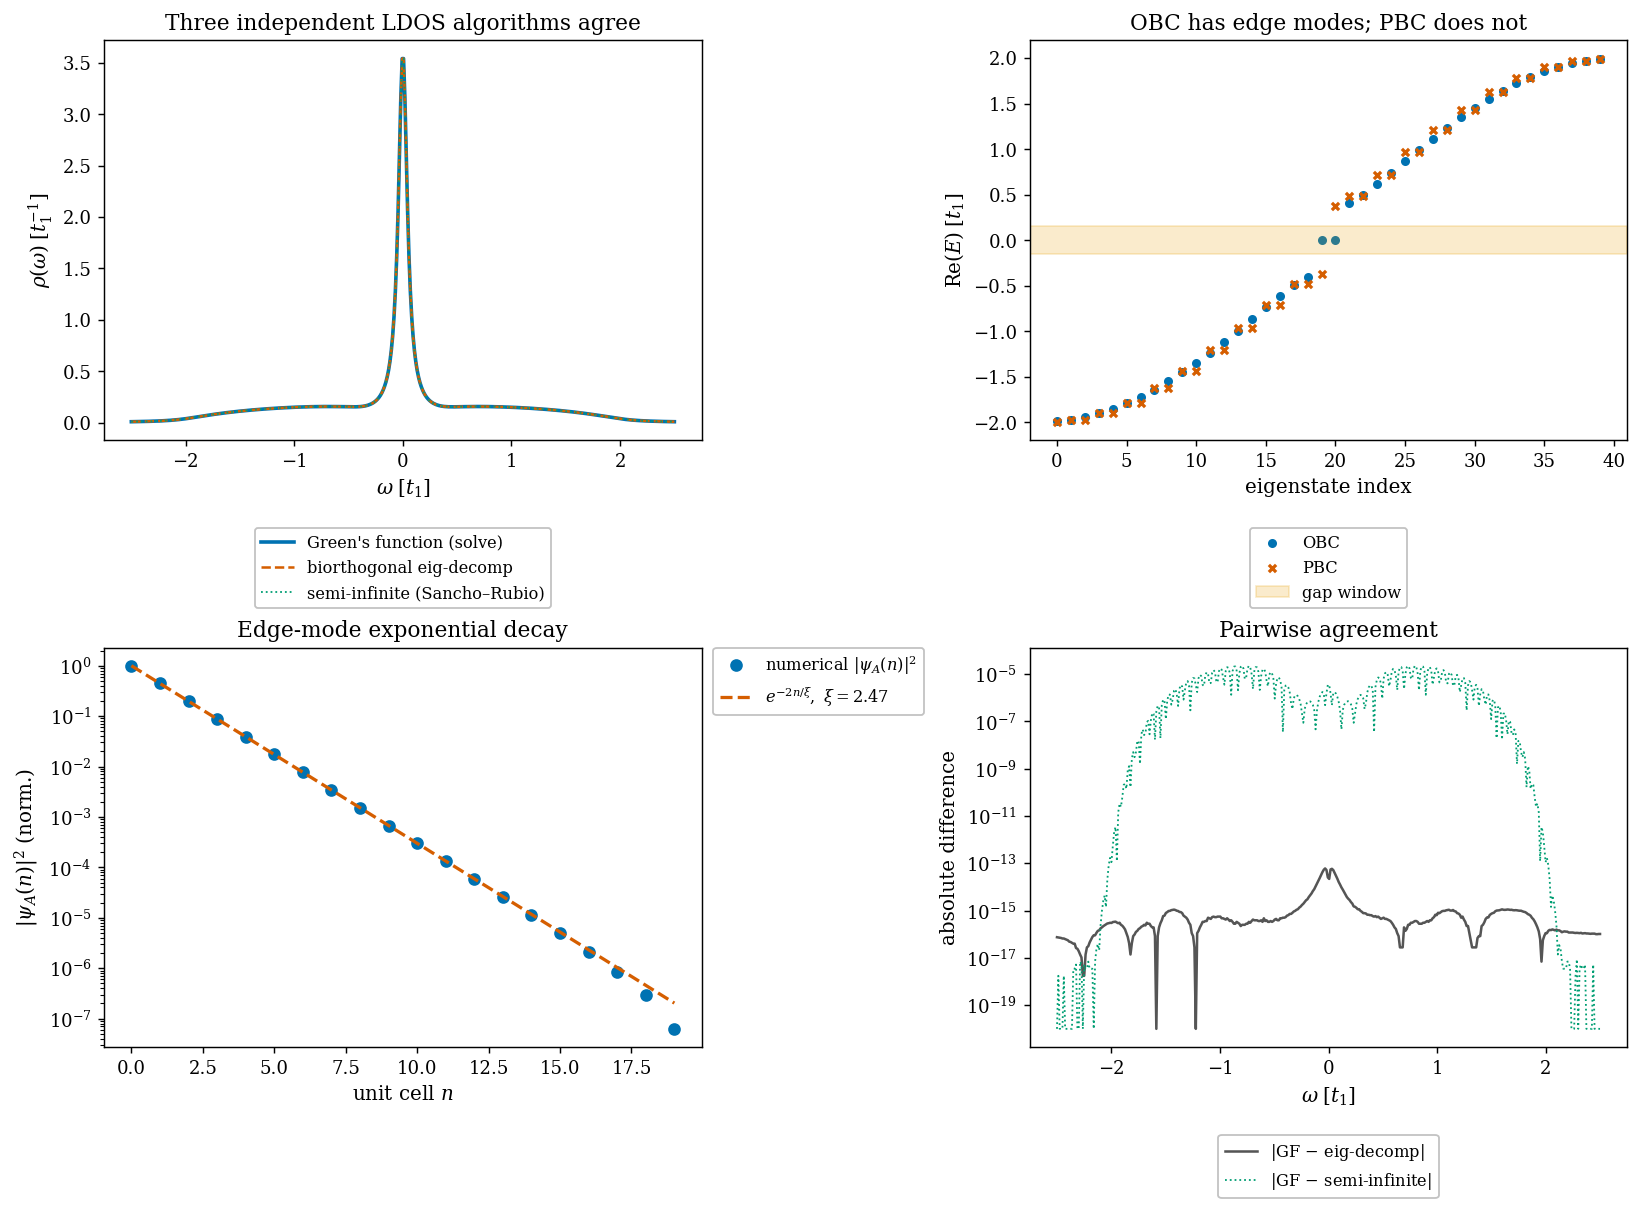

In [2]:
import scipy.linalg as la
H = nt.build_ssh(p["N"], p["t1"], p["t2"], p["gamma"]); Hp = nt.build_ssh_pbc(p["N"], p["t1"], p["t2"], p["gamma"])
om = np.linspace(-2.5, 2.5, 400)
rho_gf = nt.ldos_spectrum(H, 0, om, p["eta"])
rho_ed = np.array([nt.ldos_eigdecomp(H, 0, w, p["eta"]) for w in om])
rho_s  = nt.surface_ldos_spectrum(om, p["t1"], p["t2"], p["gamma"], p["eta"], 0)
print("max|GF-ED| = %.2e" % np.max(np.abs(rho_gf-rho_ed)))
print("max|GF-surface(semi-inf)| = %.2e  (finite-size correction)" % np.max(np.abs(rho_gf-rho_s)))

obc = np.sort(la.eigvals(H).real); pbc = np.sort(la.eigvals(Hp).real)
print("in-gap states: OBC=%d, PBC=%d" % ((np.abs(obc)<0.1).sum(), (np.abs(pbc)<0.1).sum()))

evals, evecs = nt.diagonalize(H)
xi_fit = nt.fit_localization_length(evals, evecs, p["N"]); xi_th = nt.localization_length(p["t1"], p["t2"])
print("xi: theory=%.4f fit=%.4f (%.1f%%)" % (xi_th, xi_fit, abs(xi_th-xi_fit)/xi_th*100))
print("edge weight: numeric=%.5f analytic=%.5f" %
      (nt.edge_mode_spectral_weight(H, 0), nt.analytic_edge_weight(p["t1"], p["t2"])))
ow = np.linspace(-10, 10, 3000)
print("sum rule integral (site 0) = %.4f" % np.trapezoid(nt.ldos_spectrum(H, 0, ow, p["eta"]), ow))

info = nt.find_edge_modes(evals, evecs); psi = evecs[:, info["protected_idx"][0]]
iA = np.abs(psi[0::2])**2; iA /= iA[0]
fig, _ = P.plot_validation(om, rho_gf, rho_ed, rho_s, obc, pbc, np.arange(p["N"]), iA, xi_th, p["gap_hw"])
P.save_fig(fig, figdir("08_numerical_validation"), "01_cross_validation"); plt.show()